In [1]:
import sys, platform
print(sys.executable)
print(platform.platform())

/sw/auto/rocky8d/epyc4_a16/software/Python/3.10.4-GCCcore-11.3.0/bin/python
Linux-4.18.0-553.58.1.el8_10.x86_64-x86_64-with-glibc2.28


In [2]:
import sys
print("Python:", sys.version)

import torch
print("Torch version:", torch.__version__)

import tifffile
print("Tifffile loaded")

import matplotlib.pyplot as plt
print("Matplotlib loaded")

Python: 3.10.4 (main, Jun  8 2025, 11:17:16) [GCC 11.3.0]
Torch version: 2.10.0+cu128
Tifffile loaded
Matplotlib loaded


In [3]:
!module avail PyTorch

No module(s) or extension(s) found!
Module defaults are chosen based on Find First Rules due to Name/Version/Version  modules found in the module tree.
See https://lmod.readthedocs.io/en/latest/060_locating.html for details.

If the avail list is too long consider trying:

"module --default avail" or "ml -d av" to just list the default modules.
"module overview" or "ml ov" to display the number of modules for each name.

Use "module spider" to find all possible modules and extensions.
Use "module keyword key1 key2 ..." to search for all possible modules matching
any of the "keys".


>

In [4]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import torch
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
GPU available: True


In [6]:
import sys, site, os
print("Kernel python:", sys.executable)
print("User site:", site.getusersitepackages())
print("sys.path contains user site?:", site.getusersitepackages() in sys.path)

Kernel python: /sw/auto/rocky8d/epyc4_a16/software/Python/3.10.4-GCCcore-11.3.0/bin/python
User site: /home/s4906996/.local/lib/python3.10/site-packages
sys.path contains user site?: True


In [7]:
import sys
!{sys.executable} -m pip install --user --upgrade pip
!{sys.executable} -m pip install --user torch torchvision torchaudio

In [8]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA available: True


In [9]:
import sys
!{sys.executable} -m pip install --user -U cellpose tifffile opencv-python-headless matplotlib scikit-image

In [10]:
from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt


In [11]:
pwd


'/home/s4906996/cellposeSAM'

In [12]:
ls


614399s1d20241213.tif  Untitled.ipynb


In [13]:
cd ..

/home/s4906996


In [14]:
ls


cellposeSAM/  Documents/  Music/     Pictures/  Templates/      Videos/
Desktop/      Downloads/  ondemand/  Public/    Untitled.ipynb


In [15]:
from pathlib import Path

data_dir = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")
print("Exists:", data_dir.exists())
print("First 30 files:")
for p in sorted(data_dir.glob("*"))[:30]:
    print(p.name)

print("\nTIFF files:")
tiffs = sorted(list(data_dir.glob("*.tif"))) + sorted(list(data_dir.glob("*.tiff")))
for p in tiffs[:30]:
    print(p.name)
print("\nCount:", len(tiffs))

Exists: True
First 30 files:
._614399S2D20250113.tif
._614399s1d20241213.tif
._614399s1d20250108.tif
._671485s2d20250728.tif
614399S2D20250113.tif
614399s1d120250113.tif
614399s1d20241213.tif
614399s1d20250108.tif
614400s1d20241218.tif
614400s1d20250108.tif
614401s1d20250114.tif
614401s1d20250414.tif
614404s1d20250115.tif
671461s1d20250728.tif
671462s1d20250728.tif
671463s1d20250701.tif
671463s2d20250701.tif
671463s2d20250707.tif
671480s1d20250325.tif
671480s1d20250709.tif
671481s1d20250326.tif
671482s1d20250218.tif
671485s1d20250728.tif
671485s2d20250728.tif
671486s1d20250728.tif
671488s1d20250326.tif

TIFF files:
._614399S2D20250113.tif
._614399s1d20241213.tif
._614399s1d20250108.tif
._671485s2d20250728.tif
614399S2D20250113.tif
614399s1d120250113.tif
614399s1d20241213.tif
614399s1d20250108.tif
614400s1d20241218.tif
614400s1d20250108.tif
614401s1d20250114.tif
614401s1d20250414.tif
614404s1d20250115.tif
671461s1d20250728.tif
671462s1d20250728.tif
671463s1d20250701.tif
671463s2d2025070

Loaded: /QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant/614399s1d20241213.tif
Shape: (512, 512) dtype: uint16 min/max: 32751.0 33087.0


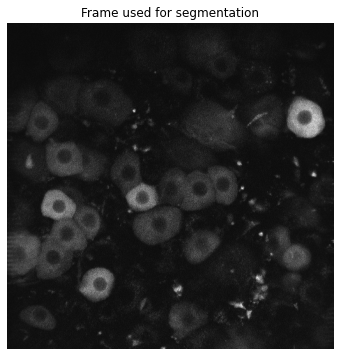

In [16]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")
img_path = data_dir / "614399s1d20241213.tif"   # <-- change this

img = tiff.imread(img_path)
print("Loaded:", img_path)
print("Shape:", img.shape, "dtype:", img.dtype, "min/max:", float(img.min()), float(img.max()))

# choose 2D slice to visualize
if img.ndim == 2:
    im2d = img
elif img.ndim == 3:
    # handle (T,H,W) vs (H,W,T)
    if img.shape[0] < 10 and img.shape[-1] > 10:
        im2d = img[:, :, img.shape[-1]//2]   # (H,W,T)
    else:
        im2d = img[img.shape[0]//2]          # (T,H,W)
else:
    raise ValueError(f"Unexpected dims: {img.shape}")

plt.figure(figsize=(6,6))
plt.imshow(im2d, cmap="gray")
plt.title("Frame used for segmentation")
plt.axis("off")
plt.show()

In [ ]:
from cellpose import models

# normalize image
im = im2d.astype("float32")
im = (im - im.min()) / (im.max() - im.min() + 1e-8)

# load model
model = models.CellposeModel(gpu=True, pretrained_model="cyto2")

# run segmentation
masks, flows, styles = model.eval(
    im,
    channels=[0,0],
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0
)

print("Detected cells:", masks.max())

pretrained model /home/s4906996/.cellpose/models/cpsam not found, using default model
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


In [1]:
import sys, os
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))

Python: 3.10.4 (main, Jun  8 2025, 11:17:16) [GCC 11.3.0]
Torch: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA A16
GPU capability: (8, 6)


In [4]:
#Step 2: Set safe environment flags (prevents OpenMP / thread blowups)

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [5]:
#Step 3: Import Cellpose safely (CPU first)


from cellpose import models
print("Cellpose imported OK")

Cellpose imported OK


In [7]:
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt

data_dir = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")

img_path = data_dir / "614399s1d20241213.tif"   # change this

img = tifffile.imread(img_path)

print("Shape:", img.shape)

Shape: (512, 512)


In [8]:
import numpy as np

# if image already 2D
if img.ndim == 2:
    im2d = img

# if time stack (T,H,W)
elif img.ndim == 3:
    im2d = img[img.shape[0] // 2]

print("2D frame shape:", im2d.shape)

2D frame shape: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

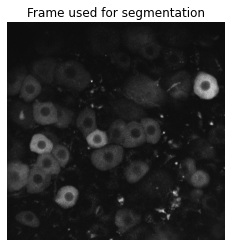

In [9]:
plt.imshow(im2d, cmap="gray")
plt.title("Frame used for segmentation")
plt.axis("off")

In [10]:
from cellpose import models

im = im2d.astype("float32")
im = (im - im.min()) / (im.max() - im.min() + 1e-8)

model = models.CellposeModel(gpu=False, pretrained_model="cyto2")

masks, flows, styles = model.eval(
    im,
    channels=[0,0],
    diameter=None
)

print("Detected cells:", masks.max())

pretrained model /home/s4906996/.cellpose/models/cpsam not found, using default model
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Detected cells: 36


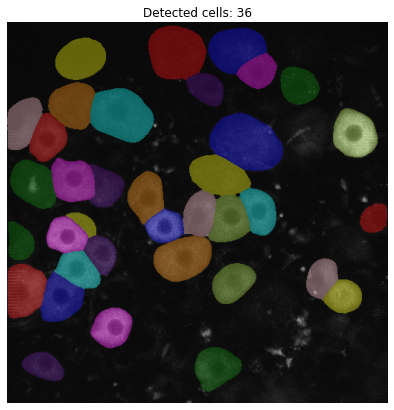

In [11]:
from skimage.color import label2rgb
import matplotlib.pyplot as plt

overlay = label2rgb(masks, image=im, bg_label=0, alpha=0.35)

plt.figure(figsize=(7,7))
plt.imshow(overlay)
plt.title(f"Detected cells: {masks.max()}")
plt.axis("off")
plt.show()

In [12]:
import tifffile
from pathlib import Path

output_dir = Path("/home/s4906996/cellpose_results")
output_dir.mkdir(exist_ok=True)

tifffile.imwrite(output_dir/"drg_masks.tif", masks.astype("uint16"))

print("Masks saved to:", output_dir)

Masks saved to: /home/s4906996/cellpose_results


In [13]:
#running the model for all the .tiff images 
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from cellpose import models
from skimage.color import label2rgb

# INPUT folder
IN_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")

# OUTPUT folder (write somewhere you have permission)
OUT_DIR = Path.home() / "cellpose_masks_resonant"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", IN_DIR)
print("Output:", OUT_DIR)

# Use CPU first for stability; change to gpu=True once you're confident it won't crash
USE_GPU = False
MODEL_NAME = "cyto2"

model = models.CellposeModel(gpu=USE_GPU, pretrained_model=MODEL_NAME)
print("Model loaded:", MODEL_NAME, "GPU:", USE_GPU)

pretrained model /home/s4906996/.cellpose/models/cpsam not found, using default model


Input: /QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant
Output: /home/s4906996/cellpose_masks_resonant
Model loaded: cyto2 GPU: False


In [17]:
from pathlib import Path
import tifffile

IN_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")
tiff_files = sorted(list(IN_DIR.glob("*.tif")) + list(IN_DIR.glob("*.tiff")))

bad = []
ok = []

for fp in tiff_files:
    try:
        with tifffile.TiffFile(fp) as tif:
            _ = tif.pages[0].shape  # touch first page
        ok.append(fp)
    except Exception as e:
        bad.append((fp.name, str(e)))

print("Total:", len(tiff_files))
print("OK:", len(ok))
print("BAD:", len(bad))
for name, err in bad[:10]:
    print("BAD:", name, "|", err)

Total: 26
OK: 22
BAD: 4
BAD: ._614399S2D20250113.tif | not a TIFF file b'\x00\x05\x16\x07'
BAD: ._614399s1d20241213.tif | not a TIFF file b'\x00\x05\x16\x07'
BAD: ._614399s1d20250108.tif | not a TIFF file b'\x00\x05\x16\x07'
BAD: ._671485s2d20250728.tif | not a TIFF file b'\x00\x05\x16\x07'


In [18]:
tiff_files = sorted(
    [f for f in IN_DIR.glob("*.tif") if not f.name.startswith(".")] +
    [f for f in IN_DIR.glob("*.tiff") if not f.name.startswith(".")]
)

In [19]:
print("Total valid TIFF images:", len(tiff_files))
for f in tiff_files[:5]:
    print("Example file:", f.name)

Total valid TIFF images: 22
Example file: 614399S2D20250113.tif
Example file: 614399s1d120250113.tif
Example file: 614399s1d20241213.tif
Example file: 614399s1d20250108.tif
Example file: 614400s1d20241218.tif


In [21]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import csv

from cellpose import models
from skimage.color import label2rgb

# INPUT folder
IN_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")

# OUTPUT folder (safe write location)
OUT_DIR = Path.home() / "cellpose_masks_resonant"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ignore hidden files like ._xxxx.tif
tiff_files = sorted(
    [f for f in IN_DIR.glob("*.tif") if not f.name.startswith(".")] +
    [f for f in IN_DIR.glob("*.tiff") if not f.name.startswith(".")]
)

print("Valid TIFF files:", len(tiff_files))
print("Output:", OUT_DIR)

# Model (start CPU for stability; later you can set USE_GPU=True)
USE_GPU = False
MODEL_NAME = "cyto2"
model = models.CellposeModel(gpu=USE_GPU, pretrained_model=MODEL_NAME)

# How to convert a time-stack TIFF (T,H,W) to a 2D image for segmentation
PROJ_METHOD = "mean"   # "mean" works well for calcium stacks; can try "median" or "middle"

pretrained model /home/s4906996/.cellpose/models/cpsam not found, using default model


Valid TIFF files: 22
Output: /home/s4906996/cellpose_masks_resonant


In [22]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import csv

from cellpose import models
from skimage.color import label2rgb

# INPUT folder
IN_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")

# OUTPUT folder (safe write location)
OUT_DIR = Path.home() / "cellpose_masks_resonant"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ignore hidden files like ._xxxx.tif
tiff_files = sorted(
    [f for f in IN_DIR.glob("*.tif") if not f.name.startswith(".")] +
    [f for f in IN_DIR.glob("*.tiff") if not f.name.startswith(".")]
)

print("Valid TIFF files:", len(tiff_files))
print("Output:", OUT_DIR)

# Model (start CPU for stability; later you can set USE_GPU=True)
USE_GPU = False
MODEL_NAME = "cyto2"
model = models.CellposeModel(gpu=USE_GPU, pretrained_model=MODEL_NAME)

# How to convert a time-stack TIFF (T,H,W) to a 2D image for segmentation
PROJ_METHOD = "mean"   # "mean" works well for calcium stacks; can try "median" or "middle"

pretrained model /home/s4906996/.cellpose/models/cpsam not found, using default model


Valid TIFF files: 22
Output: /home/s4906996/cellpose_masks_resonant


In [23]:
FLOW_THR = 0.4
CELLPROB_THR = 0.0
DIAMETER = None   # later you can tune e.g. 3560 for DRG soma

counts_rows = []
failed_rows = []

for i, fp in enumerate(tiff_files, start=1):
    try:
        print(f"[{i}/{len(tiff_files)}] {fp.name}")

        # robust TIFF read
        with tifffile.TiffFile(fp) as tif:
            img = tif.asarray()

        # choose 2D image for segmentation
        if img.ndim == 2:
            im2d = img
        elif img.ndim == 3:
            if PROJ_METHOD == "mean":
                im2d = img.mean(axis=0)
            elif PROJ_METHOD == "median":
                im2d = np.median(img, axis=0)
            else:  # "middle"
                im2d = img[img.shape[0] // 2]
        else:
            raise ValueError(f"Unsupported TIFF shape: {img.shape}")

        # normalize 0..1
        im2d = im2d.astype("float32")
        im2d = (im2d - im2d.min()) / (im2d.max() - im2d.min() + 1e-8)

        # run Cellpose
        masks, flows, styles = model.eval(
            im2d,
            diameter=DIAMETER,
            flow_threshold=FLOW_THR,
            cellprob_threshold=CELLPROB_THR
        )

        n_cells = int(masks.max())
        counts_rows.append([fp.name, n_cells, str(img.shape), PROJ_METHOD])

        # save mask labels
        tifffile.imwrite(OUT_DIR / f"{fp.stem}_masks.tif", masks.astype("uint16"))

        # save overlay for QC
        overlay = label2rgb(masks, image=im2d, bg_label=0, alpha=0.35)
        plt.figure(figsize=(6,6))
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"{fp.name} | cells={n_cells}")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"{fp.stem}_overlay.png", dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close()

    except Exception as e:
        failed_rows.append([fp.name, str(e)])
        print("  -> SKIPPED:", e)

# write CSV outputs
counts_csv = OUT_DIR / "trace_counts.csv"
failed_csv = OUT_DIR / "failed_files.csv"

with open(counts_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["filename", "cells_detected", "tiff_shape", "projection_method"])
    w.writerows(counts_rows)

with open(failed_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["filename", "error"])
    w.writerows(failed_rows)

print("\nDONE")
print("Counts saved to:", counts_csv)
print("Failures saved to:", failed_csv)
print("Outputs folder:", OUT_DIR)

[1/22] 614399S2D20250113.tif
[2/22] 614399s1d120250113.tif
[3/22] 614399s1d20241213.tif
[4/22] 614399s1d20250108.tif
[5/22] 614400s1d20241218.tif
[6/22] 614400s1d20250108.tif
[7/22] 614401s1d20250114.tif
[8/22] 614401s1d20250414.tif
[9/22] 614404s1d20250115.tif
[10/22] 671461s1d20250728.tif
[11/22] 671462s1d20250728.tif
[12/22] 671463s1d20250701.tif
[13/22] 671463s2d20250701.tif
[14/22] 671463s2d20250707.tif
[15/22] 671480s1d20250325.tif
[16/22] 671480s1d20250709.tif
[17/22] 671481s1d20250326.tif
[18/22] 671482s1d20250218.tif
[19/22] 671485s1d20250728.tif
[20/22] 671485s2d20250728.tif
[21/22] 671486s1d20250728.tif
[22/22] 671488s1d20250326.tif

DONE
Counts saved to: /home/s4906996/cellpose_masks_resonant/trace_counts.csv
Failures saved to: /home/s4906996/cellpose_masks_resonant/failed_files.csv
Outputs folder: /home/s4906996/cellpose_masks_resonant
